In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Changed snim to sns
import warnings
warnings.filterwarnings("ignore")


# set style
sns.set(style='whitegrid')

Step: Load and inspect the dataset

Step:2 Clean and preprocess the data

Step:3 Analyze funding trends over time

Step:4 Identify top funded sectors, cities, startups

Step:5 Analyze investor behavior

Step:6 Analyze investment types and stages

Step:7 Correlation analysis

Step:8 Identify funding outliers and growth trends

Stec:9 Advanced analysis (funding stage, investor types etc)

1. load inspect the dataset
objective:understand

In [ ]:
def readcsv(filepath,filename):
  import os
  os.chdir(filepath)
  file=pd.read_excel(filename)
  return file
filepath="/content/drive/MyDrive/KLENIPPANI"
filename="startup_funding138 (1).xlsx"


df=readcsv(filepath,filename)

In [ ]:
print(pd.DataFrame(df.head(3)))

   SNo                 Date   StartupName  Industry_Vertical  \
0    0  2017-01-08 00:00:00      TouchKin         Technology   
1    1  2017-02-08 00:00:00       Ethinos         Technology   
2    2  2017-02-08 00:00:00  Leverage Edu  Consumer Internet   

                                     SubVertical City_Location  \
0                       Predictive Care Platform     Bangalore   
1                       Digital Marketing Agency        Mumbai   
2  Online platform for Higher Education Services     New Delhi   

                                      Investors_Name  InvestmentType  \
0                                        Kae Capital  Private Equity   
1                         Triton Investment Advisors  Private Equity   
2  Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...    Seed Funding   

   Amount_In_INR Remarks  
0      1300000.0     NaN  
1            NaN     NaN  
2            NaN     NaN  


In [ ]:
# inspect first few rows
print("first 5 rows:")
print(df.head())

#basic info
print("\nDataset info:")
print(df.info())

#check for missing value
print("\nmissing value:")
print(df.isnull().sum())

first 5 rows:
   SNo                 Date   StartupName  Industry_Vertical  \
0    0  2017-01-08 00:00:00      TouchKin         Technology   
1    1  2017-02-08 00:00:00       Ethinos         Technology   
2    2  2017-02-08 00:00:00  Leverage Edu  Consumer Internet   
3    3  2017-02-08 00:00:00          Zepo  Consumer Internet   
4    4  2017-02-08 00:00:00  Click2Clinic  Consumer Internet   

                                     SubVertical City_Location  \
0                       Predictive Care Platform     Bangalore   
1                       Digital Marketing Agency        Mumbai   
2  Online platform for Higher Education Services     New Delhi   
3                         DIY Ecommerce platform        Mumbai   
4                  healthcare service aggregator     Hyderabad   

                                      Investors_Name  InvestmentType  \
0                                        Kae Capital  Private Equity   
1                         Triton Investment Advisors  Privat

Step 2: Clean and Preprocess the Data

Objective: Prepare the dataset for analysis by handling missing values, standardizing names, and normalizing fundi

Explanationt

Columns are cleaned and standardized.

Missing values are filled with appropriate defaults.

Date column is converted to datetime and used to extract year and month.

Funding amounts are normalized to INR using a custom function.

Missing funding values are filled with median to avoid distortion.

In [ ]:
df.columns

Index(['SNo', 'Date', 'StartupName', 'Industry_Vertical', 'SubVertical',
       'City_Location', 'Investors_Name', 'InvestmentType', 'Amount_In_INR',
       'Remarks'],
      dtype='object')

In [ ]:
# file missing values
df['Industry_Vertical']=df['Industry_Vertical'].fillna('others')
df['SubVertical']=df['SubVertical'].fillna('not specified')
df['City_Location']=df['City_Location'].fillna('not specified')
df['Investors_Name']=df['Investors_Name'].fillna('undisclosed')

In [ ]:
#Convert date column to datetime and extract year/month
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df ['Month'] = df['Date'].dt.month

In [ ]:
df.columns

Index(['SNo', 'Date', 'StartupName', 'Industry_Vertical', 'SubVertical',
       'City_Location', 'Investors_Name', 'InvestmentType', 'Amount_In_INR',
       'Remarks', 'Year', 'Month'],
      dtype='object')

In [ ]:
# apply the function to amount column
df['Amount_In_INR'] = df['Amount_In_INR'].fillna(df['Amount_In_INR'].median())

In [ ]:
# save cleaned data
df.to_csv("cleaned_startup_funding.csv", index=False)

Step 3: Funding Trends Over Time

Objective: Analyze how funding has evolved year-over-year and month-over-month.

Explanation:

A countplot shows the number of funding deals over the years.

A line plot shows total funding amount per year, helping identify growth or decline trends.

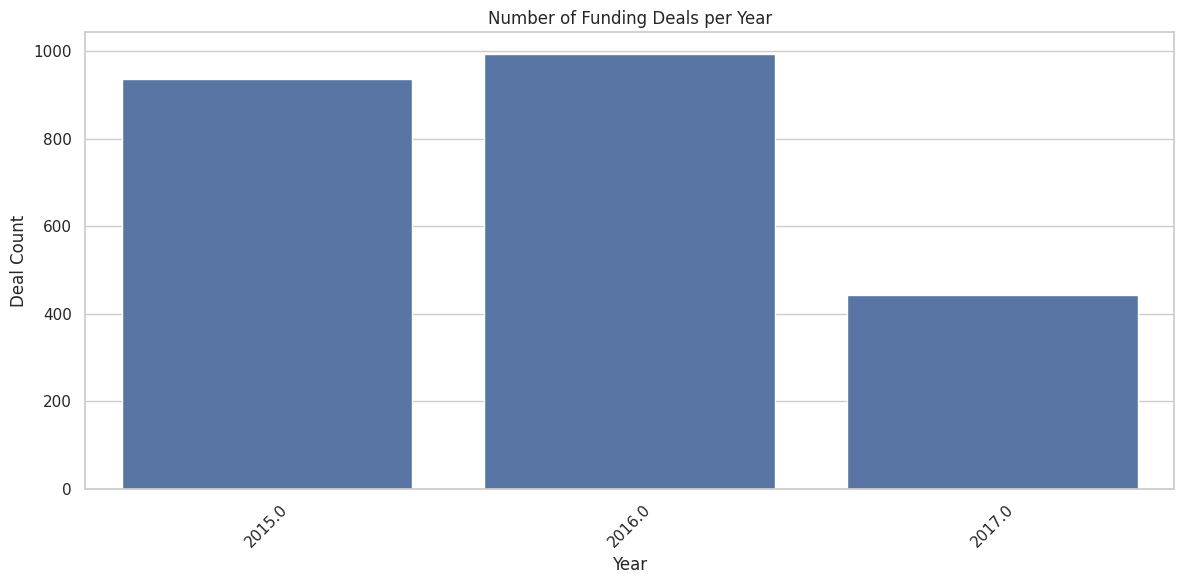

In [ ]:
      # Number of deals per year
plt.figure(figsize=(12, 6))
sns.countplot(x='Year', data=df)
plt.title("Number of Funding Deals per Year")
plt.xlabel("Year")
plt.ylabel("Deal Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# total funding per year
yearly_funding = df.groupby('Year')['Amount_In_INR'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Amount_In_INR', data=yearly_funding,marker='o')
plt.title("Total Funding Amount per Year")
plt.xlabel("Year")
plt.ylabel("Total Funding Amount (INR)")
plt.grid(True)

plt.tight_layout()
plt.show()

Step 4: Top Funded Sectors, Cities, and Startups

Objective: Identify the most funded sectors, cities, and startups.

Explanation:

Bar charts show which sectors, cities, and startups are receiving the most attention and fundin

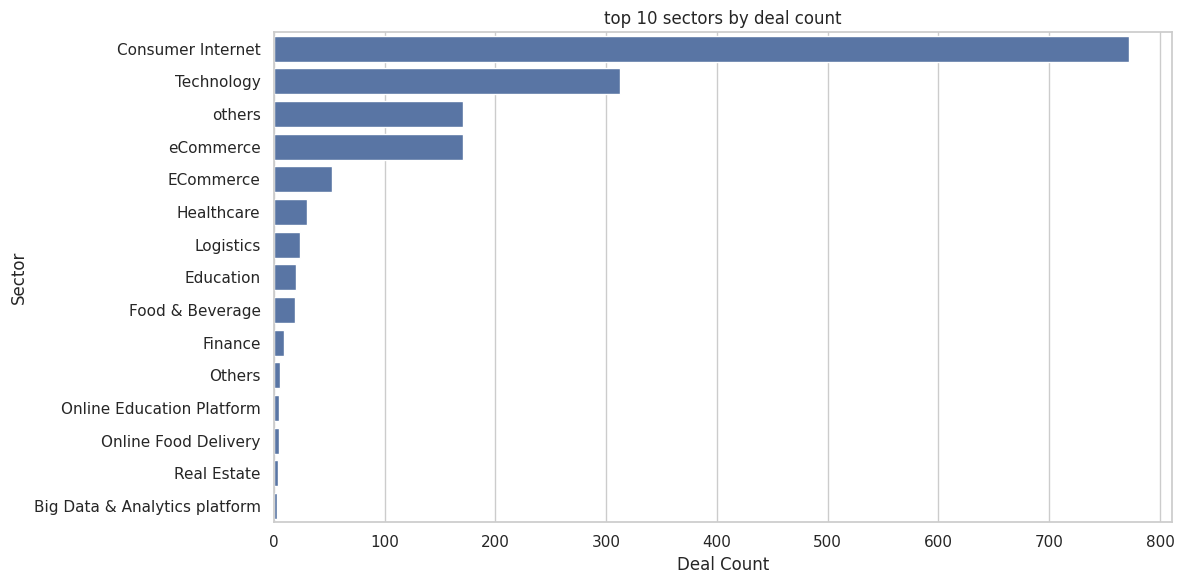

In [ ]:
 # top setons by deal cout
 top_sectors = df['Industry_Vertical'].value_counts().head(15)
 plt.figure(figsize=(12, 6))
 sns.barplot(x=top_sectors.values, y=top_sectors.index)
 plt.title("top 10 sectors by deal count")
 plt.xlabel("Deal Count")
 plt.ylabel("Sector")
 plt.tight_layout()
 plt.show()

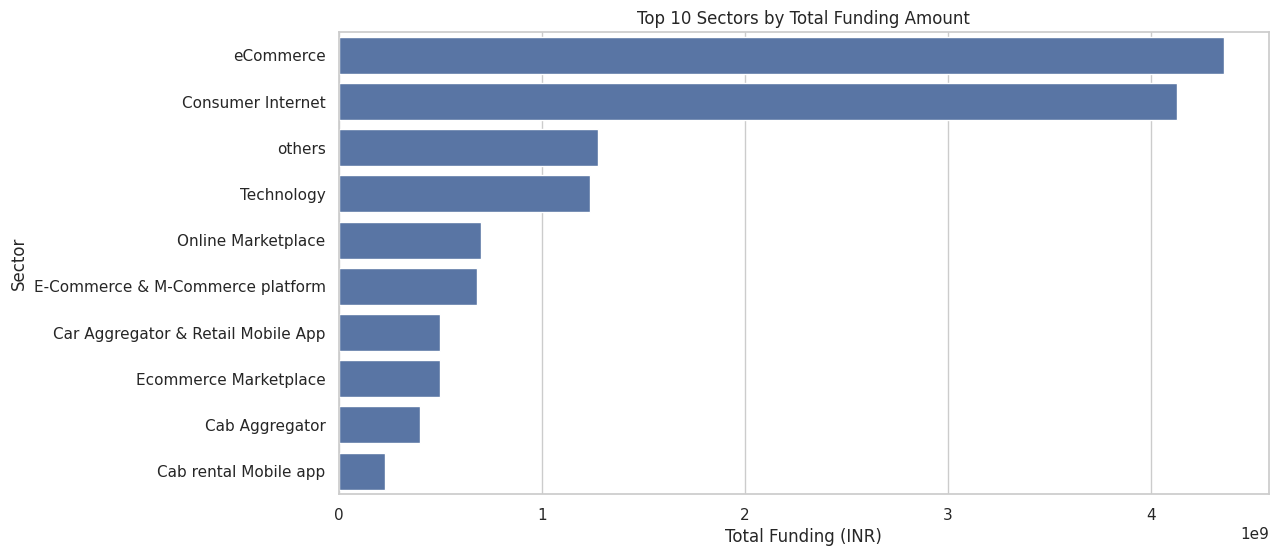

In [ ]:
# top sectors by total funding
df['Industry_Vertical'] = df['Industry_Vertical'].replace({'ECommerce':'eCommerce'})
sector_funding = df.groupby('Industry_Vertical')['Amount_In_INR'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=sector_funding.values, y=sector_funding.index)
plt.title("Top 10 Sectors by Total Funding Amount")
plt.xlabel("Total Funding (INR)")
plt.ylabel("Sector")
plt.show()

Step 5: Investor Analysis

Objective: Understand which investors are most active and which sectors they invest in.

Explanation:

Investors are split into individual names.

Top investors are identified by number of deals and total funding.

In [ ]:
# split multiple inverstors and count
inverstors_df = df[['StartupName','Investors_Name','Amount_In_INR']].copy()
inverstors_df['Investors_Name'] = inverstors_df['Investors_Name'].str.split(',')
inverstors_df = inverstors_df.explode('Investors_Name').dropna()
inverstors_df['Investors_Name'] = inverstors_df['Investors_Name'].str.strip().str.title()

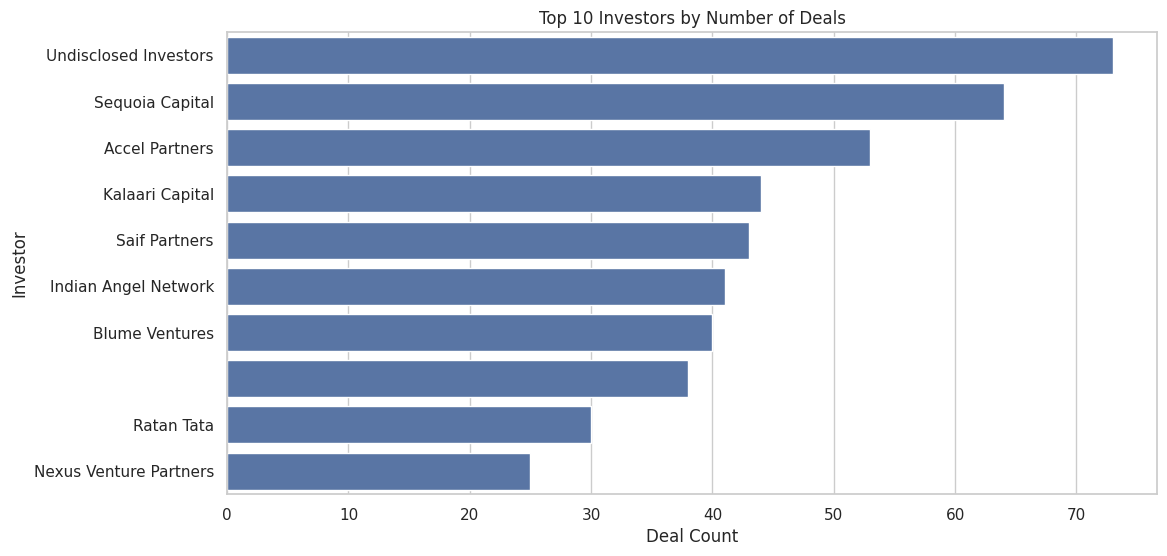

In [ ]:
#Top Investors by number of deals
top_investors_deals = inverstors_df['Investors_Name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_investors_deals.values, y=top_investors_deals.index)
plt.title("Top 10 Investors by Number of Deals")
plt.xlabel("Deal Count")
plt.ylabel("Investor")
plt.show()

step6:investing type analysis
object:understand the type of investments(seed seriesA etc)


explanation:

.this helps identify the stage of star


In [ ]:
df.columns

Index(['SNo', 'Date', 'StartupName', 'Industry_Vertical', 'SubVertical',
       'City_Location', 'Investors_Name', 'InvestmentType', 'Amount_In_INR',
       'Remarks', 'Year', 'Month'],
      dtype='object')

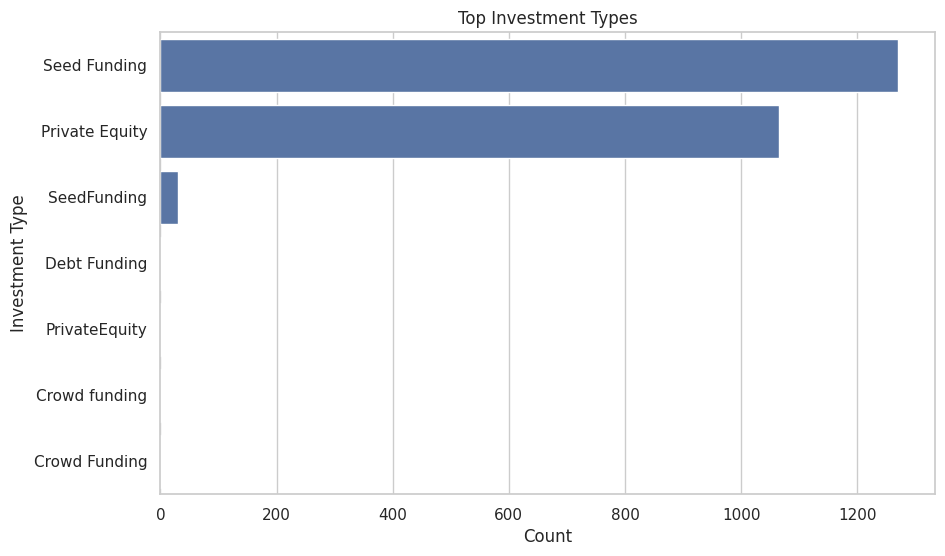

In [ ]:
investment_type = df['InvestmentType'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=investment_type.values, y=investment_type.index)
plt.title("Top Investment Types")
plt.xlabel("Count")
plt.ylabel("Investment Type")
plt.show()

Step 7: Correlation Between Sector and Investment Type

Objective: See which sectors attract which types of funding.

Explanation:

A heatmap shows which sectors are dominated by which investment types

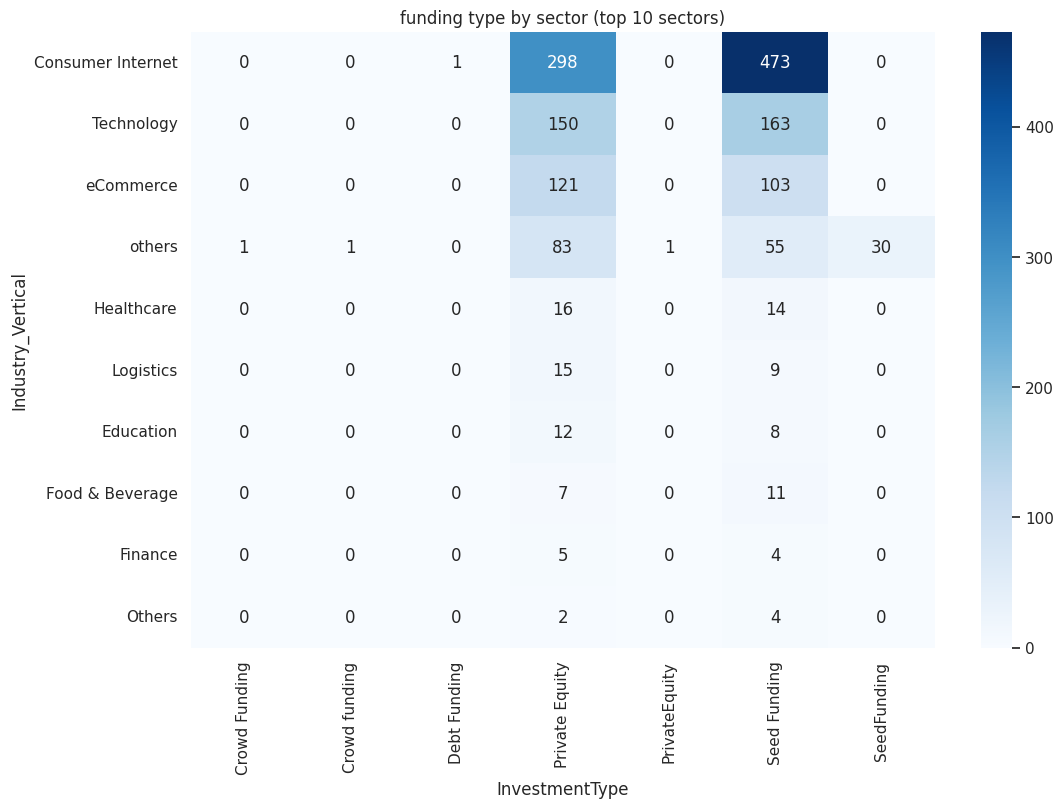

In [ ]:
sector_tage = pd.crosstab(df['Industry_Vertical'], df['InvestmentType'])
sector_tage = sector_tage.loc[sector_tage.sum(axis=1).sort_values(ascending=False).head(10).index]
plt.figure(figsize=(12, 8))
sns.heatmap(sector_tage, annot=True, cmap='Blues', fmt='d')
plt.title("funding type by sector (top 10 sectors)")
plt.show()

Step 8: Funding Distribution and Outliers

Objective: Understand how funding is distributed and identify outliers.

Explanation:

Histogram and boxplot help understand skewness and identify outliers like Paytm or Flipkart.

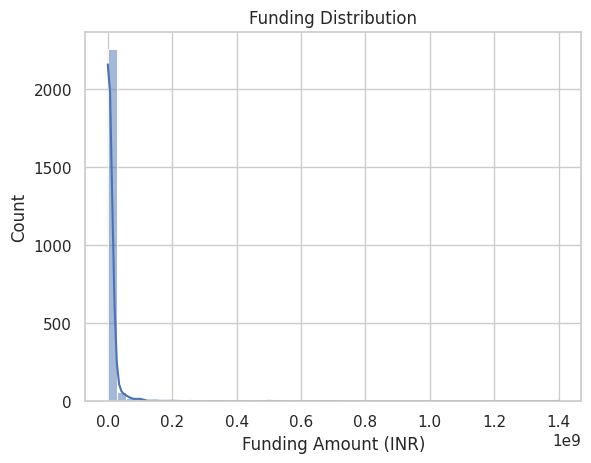

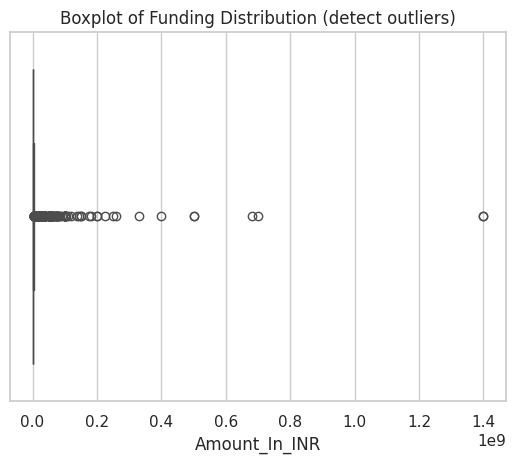

In [41]:
sns.histplot(df['Amount_In_INR'], bins=50, kde=True)
plt.title("Funding Distribution")
plt.xlabel("Funding Amount (INR)")
plt.show()

sns.boxplot(x=df['Amount_In_INR'])
plt.title("Boxplot of Funding Distribution (detect outliers)")
plt.show()


 Growth Trend of Top Sectors

Objective: Identify sectors with the highest growth potential.

Explanation:

Helps identify emerging sectors that may offer future opportunities.

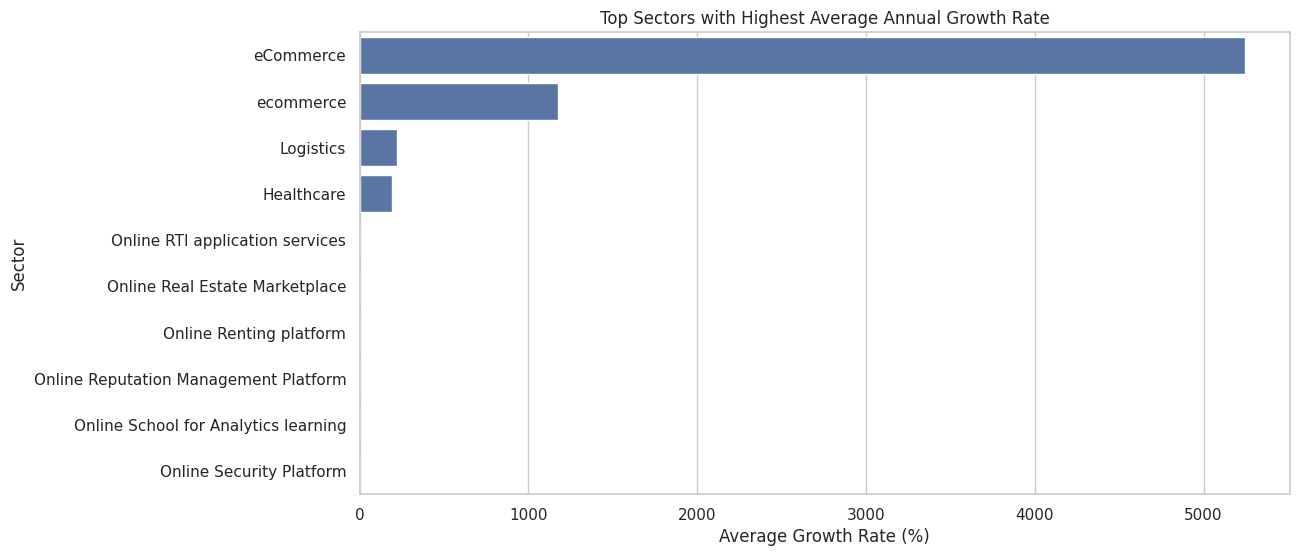

In [ ]:
sector_yearly = df.groupby(['Year', 'Industry_Vertical'])['Amount_In_INR'].sum().unstack()#.f

sector_growth = sector_yearly.pct_change().mean().sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))
sns.barplot(x=sector_growth.values * 100, y=sector_growth.index)
plt.title("Top Sectors with Highest Average Annual Growth Rate")
plt.xlabel("Average Growth Rate (%)")
plt.ylabel("Sector")
plt.show()

In [42]:
sector_yearly

Industry_Vertical,360-degree view creating platform,3D Printer Manufacturer,API Workflow platform,Activity Based Social Network,Advertising & Marketing Community Networking platform,Affordable Education,Affordable Hotel Booking Online,Algorithmic Match Making Platform,Alternate Mobile Monetization platform,App Analytics platform,...,online tiffin service aggregator,others,pre-owned Luxury online apparel seller,pre-used apparel shopping mobile app,pre-used luxury item Marketplace,proximity marketing & Mobile Advertising platform,residential rental management platform,solar products and services marketplace,"virtual reality, 3d simulation and stereoscopic products",visual search and discovery platform
Year,,,,,,,,,,,,,,,,,,,,,
2015.0,1070000.0,3000000.0,1000000.0,1070000.0,1000000.0,650000.0,5000000.0,1070000.0,5000000.0,500000.0,...,1070000.0,1.274411e+09,1070000.0,1000000.0,1070000.0,80000.0,640000.0,1070000.0,800000.0,1000000.0
2016.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


step10:advanced analysis

goal:add more depth to the analysis with:

.investing  type distribution

.startup funding trjectory

.Repeat investment analysis

1.investor type distribute
goal:classify into type like VC angel corporaye etc

explanation:

.investing are split into individual names.
.investor names are classified using keyword matching
.a bar chart shows the nummber of deals

In [44]:
investors_df=df[['StartupName','Investors_Name','Amount_In_INR']].copy()
investors_df['Investors_Name']=investors_df['Investors_Name'].str.split(',')
investors_df=investors_df.explode('Investors_Name').dropna()
investors_df['Investors_Name']=investors_df['Investors_Name'].str.strip().str.title()

In [45]:
def classify_investor(name):

  name = name.lower()

  if any(word in name for word in ['capital', 'ventures', 'partners', 'fund', 'vc', 'labs']):
    return 'VC'

  elif any(word in name for word in ('angel', 'network')):
    return 'Angel'

  elif any(word in name for word in ('corp', 'limited', 'pvt', 'ltd', 'inc')):
    return 'Corporate'
  else:
    return 'Other'

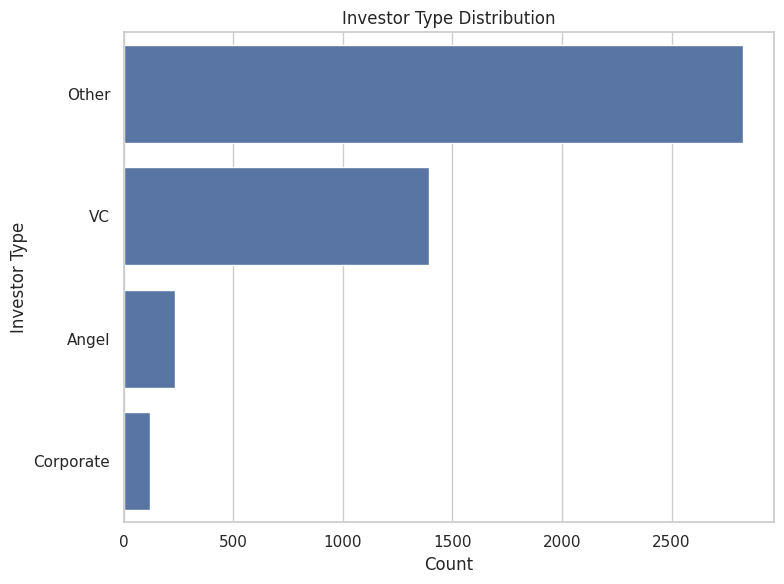

In [46]:
investors_df['Investor_Type'] = investors_df['Investors_Name'].apply(classify_investor)

investor_type_counts = investors_df['Investor_Type'].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(x=investor_type_counts.values, y=investor_type_counts.index)

plt.title("Investor Type Distribution")

plt.xlabel("Count")

plt.ylabel("Investor Type")

plt.tight_layout()

plt.show()

2. Startup Funding Trajectory

Goal: Track how top startups grew in terms of funding over time.

Explanation:

Startups are grouped by name and year.

Cumulative funding is calculated.

A line plot shows the funding growth of the top 5 startups over time

In [48]:
#Group by startup and year, then compute cumulative funding

startup_growth = df.groupby(['StartupName', 'Year'])['Amount_In_INR'].sum().unstack()


In [58]:

#Select top 5 funded startups

top_startups = startup_growth.sum(axis=1).sort_values(ascending=False).head(5).index

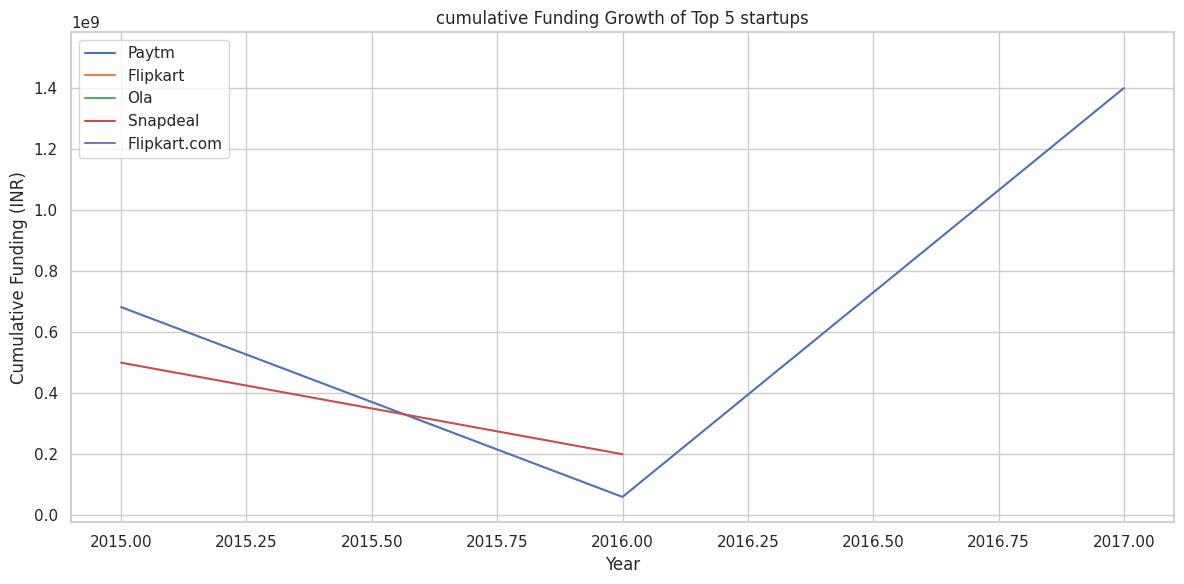

In [59]:
plt.figure(figsize=(12,6))

  plt.plot(startup_growth.loc[startup].index,startup_growth.loc[startup].values ,label=startup)
plt.title("cumula
tive Funding Growth of Top 5 startups")
plt.xlabel("Year")
plt.ylabel("Cumulative Funding (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout(.show()
